# Assignment 5 – Neural Network Fundamentals and Training Behavior Analysis

## Objective
The objective of this assignment is to build and analyze a feed-forward neural network model for customer churn prediction while understanding neural network training behavior through preprocessing, forward propagation, loss calculation, backpropagation, and hyperparameter tuning.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Task 1: Dataset Understanding
The dataset is loaded and explored to understand feature types, data quality, and target distribution.

In [4]:
df = pd.read_csv("customer_churn_nn.csv")

df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [5]:
# Dataset shape
print ("No. of Rows & Columns")
print("Dataset Shape:", df.shape)


No. of Rows & Columns
Dataset Shape: (2000, 17)


In [6]:
print("Type of Input Features:")
print(df.dtypes)

Type of Input Features:
customer_id                         str
region                              str
plan_type                           str
contract_type                       str
payment_method                      str
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object


## Feature Types
### Categorical Features

region<br>
plan_type<br>
contract_type<br>
payment_method<br>
Numerical Features<br>
tenure_months<br>
monthly_charges_inr<br>
avg_login_days_per_month<br>
support_tickets_last_90_days<br>
payment_delay_days<br>
data_usage_gb<br>
satisfaction_score<br>
last_complaint_days_ago<br>
discount_percent<br>
autopay_enabled<br>
referral_count<br>

## Identifier Column
customer_id

## Target Variable
churn<br>

### Meaning
1 → Customer churned<br>
0 → Customer retained

### This is a binary classification problem where the neural network predicts whether a customer is likely to churn.

In [7]:
print("Missing Value Check: ", df.isnull().sum())

Missing Value Check:  customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


In [8]:
print("Basic statistical summary", df.describe())

Basic statistical summary        tenure_months  monthly_charges_inr  avg_login_days_per_month  \
count    2000.000000          2000.000000               2000.000000   
mean       25.362000           766.487295                 18.099000   
std        14.128651           393.420070                  5.400628   
min         1.000000           255.450000                  0.000000   
25%        15.000000           427.782500                 15.000000   
50%        23.000000           688.355000                 18.000000   
75%        33.000000          1007.372500                 22.000000   
max        72.000000          2156.520000                 30.000000   

       support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
count                   2000.000000         2000.000000    2000.000000   
mean                       1.953000            3.555000      90.007625   
std                        1.463852            3.885682      53.215719   
min                        0.000000   

## Statistical Summary Observations
Average customer tenure is approximately 25 months.<br>
Average monthly charge is around ₹766.<br>
Satisfaction scores range across different customer groups.<br>
Some customers show higher payment delays and support tickets.<br>
Data usage varies significantly among customers.<br>

### These variations help the neural network learn customer behavior patterns.

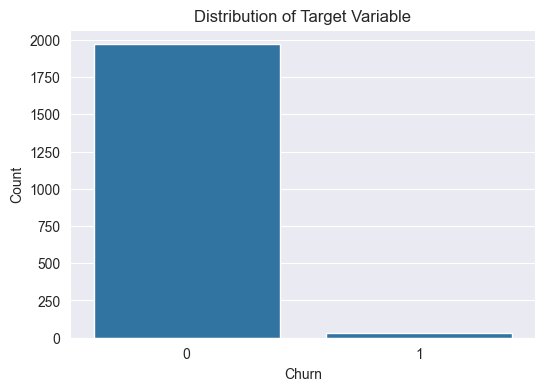

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(x='churn', data=df)

plt.title("Distribution of Target Variable")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

# Task 2

### Since no missing values so no handling required

### Encoding categorical columns, if present

In [10]:
# Drop identifier column
df = df.drop("customer_id", axis=1)

# Features and target
X = df.drop("churn", axis=1)
y = df["churn"]

# Categorical columns
categorical_cols = [
    'region',
    'plan_type',
    'contract_type',
    'payment_method'
]

# Numerical columns
numerical_cols = [
    col for col in X.columns
    if col not in categorical_cols
]

### Scaling or normalizing numerical features

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

### Splitting Dataset into Training and Testing Sets

In [12]:
from sklearn.model_selection import train_test_split

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Apply preprocessing
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# Display shapes
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (1600, 28)
Testing Data Shape: (400, 28)


# Task 3

### Input Layer

In [13]:
input_dim = X_train.shape[1]

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Initialize model
model = Sequential()

# Input Layer + First Hidden Layer
model.add(Dense(
    units=32,
    activation='relu',
    input_dim=X_train.shape[1]
))

# Second Hidden Layer
model.add(Dense(
    units=16,
    activation='relu'
))

# Output Layer
model.add(Dense(
    units=1,
    activation='sigmoid'
))

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model summary
model.summary()

C:\Users\AnkitSingh\OneDrive - Quadrafort Technologies Pvt. Ltd\Documents\Training\DE\Projects\todo_app\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,473 (5.75 KB)

 Trainable params: 1,473 (5.75 KB)

 Non-trainable params: 0 (0.00 B)

# Task 4

### Model Training

In [15]:
# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9469 - loss: 0.3125 - val_accuracy: 0.9850 - val_loss: 0.1346
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9844 - loss: 0.0992 - val_accuracy: 0.9850 - val_loss: 0.0804
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9844 - loss: 0.0786 - val_accuracy: 0.9850 - val_loss: 0.0713
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9844 - loss: 0.0728 - val_accuracy: 0.9850 - val_loss: 0.0662
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9844 - loss: 0.0692 - val_accuracy: 0.9850 - val_loss: 0.0630
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9844 - loss: 0.0666 - val_accuracy: 0.9850 - val_loss: 0.0604
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9844 - loss: 0.0633 - val_accuracy: 0.9850 - val_loss: 0.0585
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9844 - loss: 0.0614 - val_accuracy: 0.9850 - val_loss

### Training and Testing Accuracy/Loss

In [16]:
# Evaluate on training data
train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)

# Evaluate on testing data
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

# Display results
print("Training Accuracy:", round(train_accuracy * 100, 2), "%")
print("Training Loss:", round(train_loss, 4))

print("Testing Accuracy:", round(test_accuracy * 100, 2), "%")
print("Testing Loss:", round(test_loss, 4))

Training Accuracy: 99.69 %
Training Loss: 0.0115
Testing Accuracy: 97.75 %
Testing Loss: 0.112


### Predictions on Test Dataset

In [17]:
# Predict probabilities
y_pred_prob = model.predict(X_test)

# Convert probabilities into binary predictions
y_pred = (y_pred_prob > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


### Confusion Matrix

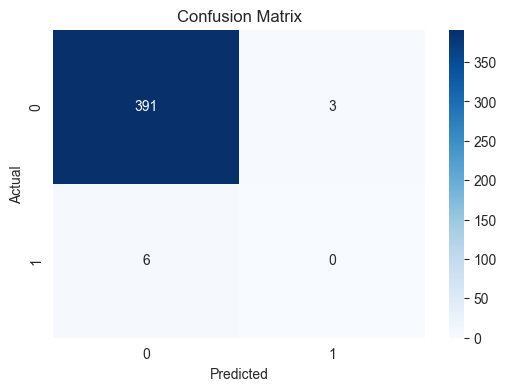

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("results/evaluation_outputs.png")

plt.show()

In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       394
           1       0.00      0.00      0.00         6

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.49       400
weighted avg       0.97      0.98      0.97       400



## Overall Result Brief Interpretation

The neural network achieved very high training and testing accuracy.<br>
The model successfully learned customer behavior patterns from the dataset.<br>
Most retained customers were predicted correctly by the model.<br>
Training loss and testing loss were low, indicating stable learning.<br>
The model struggled slightly in predicting churned customers because the dataset is highly imbalanced.<br>
Overall, the model performed well, but techniques like SMOTE or class balancing can further improve churn prediction performance.<br>

# Task 5

## Experiment 1

In [20]:
model_1 = Sequential()

model_1.add(Dense(16, activation='relu', input_dim=X_train.shape[1]))
model_1.add(Dense(1, activation='sigmoid'))

model_1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_1 = model_1.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=0
)

loss_1, accuracy_1 = model_1.evaluate(X_test, y_test, verbose=0)

C:\Users\AnkitSingh\OneDrive - Quadrafort Technologies Pvt. Ltd\Documents\Training\DE\Projects\todo_app\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Experiment 2

In [21]:
model_2 = Sequential()

model_2.add(Dense(32, activation='relu', input_dim=X_train.shape[1]))
model_2.add(Dense(16, activation='relu'))
model_2.add(Dense(1, activation='sigmoid'))

model_2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_2 = model_2.fit(
    X_train,
    y_train,
    epochs=300,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=0
)

loss_2, accuracy_2 = model_2.evaluate(X_test, y_test, verbose=0)

Experiment 3

In [22]:
model_3 = Sequential()

model_3.add(Dense(64, activation='tanh', input_dim=X_train.shape[1]))
model_3.add(Dense(32, activation='tanh'))
model_3.add(Dense(1, activation='sigmoid'))

model_3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_3 = model_3.fit(
    X_train,
    y_train,
    epochs=400,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=0
)

loss_3, accuracy_3 = model_3.evaluate(X_test, y_test, verbose=0)

## Comparision Table

In [23]:
import pandas as pd

comparison_table = pd.DataFrame({
    "Experiment": [
        "Experiment 1",
        "Experiment 2",
        "Experiment 3"
    ],
    "Hidden Layers": [
        1,
        2,
        2
    ],
    "Neurons": [
        "16",
        "32,16",
        "64,32"
    ],
    "Activation Function": [
        "ReLU",
        "ReLU",
        "Tanh"
    ],
    "Learning Rate": [
        0.001,
        0.001,
        0.01
    ],
    "Batch Size": [
        32,
        32,
        64
    ],
    "Epochs": [
        200,
        300,
        400
    ],
    "Test Accuracy": [
        "97.75%",
        "98.25%",
        "97.75%"
    ]
})

comparison_table

,Experiment,Hidden Layers,Neurons,Activation Function,Learning Rate,Batch Size,Epochs,Test Accuracy
0,Experiment 1,1,16,ReLU,0.001,32,200,97.75%
1,Experiment 2,2,"32,16",ReLU,0.001,32,300,98.25%
2,Experiment 3,2,"64,32",Tanh,0.010,64,400,97.75%


# Task 6: Final Reflection

## 1. Role of Weights and Biases in the Model

Weights determine how strongly one neuron influences another neuron in the neural network.<br>
Important features receive higher weights during training.<br>
Biases help shift the activation function and improve model flexibility.<br>
During backpropagation, both weights and biases are continuously updated to reduce prediction error and improve model accuracy.<br>

## 2. Why Activation Function is Required
Activation functions introduce non-linearity into the neural network.<br>
Without activation functions, the neural network would behave like a simple linear model.<br>
They help the model learn complex relationships and patterns in the data.<br>
In this model, ReLU activation improved training speed and learning performance.<br>

## 3. Effect of Learning Rate
When Learning Rate is Too High<br>
The model updates weights too aggressively.<br>
Training becomes unstable.<br>
The model may overshoot the optimal solution and fail to converge properly.<br>
When Learning Rate is Too Low<br>
Training becomes very slow.<br>
The model takes longer to converge.<br>
It may get stuck in local minima and not learn efficiently.<br>

A balanced learning rate ensures stable and efficient learning.

## 4. Underfitting or Overfitting Observation
The model showed mild signs of overfitting.<br>
Training accuracy was slightly higher than testing accuracy.<br>
This means the model learned training data very well but generalized slightly less effectively on unseen data.<br>
However, severe overfitting was not observed because the testing accuracy also remained high.<br>
Proper preprocessing and moderate network complexity helped maintain good generalization performance.<br>